# ABI vs DAGARBayes on Glasgow and California

This notebook loads the trained ABI network from `Checkpoints/poisson_dagar_mg.keras`, reconstructs the empirical inputs for Glasgow and California, loads the corresponding `DAGARBayes` exports from `setup_and_diagnostics/DAGARBayes`, and compares the two methods under the median probability model rule. Because the reference sampler is model-matched, the main cross-method parameter comparisons are direct for `beta_0`, `sigma_w^2`, `eta`, and `rho`.

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

from pathlib import Path
import warnings

import bayesflow as bf
import geopandas as gpd
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Data"
CHECKPOINTS_DIR = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Training/Checkpoints")
DAGARBAYES_DIR = PROJECT_DIR / "setup_and_diagnostics" / "DAGARBayes"
COMPARISON_DIR = PROJECT_DIR / "results_ABI_vs_DAGARBayes"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = CHECKPOINTS_DIR / "poisson_dagar.keras"
ABI_NUM_SAMPLES = 100_000
PPC_NUM_SAMPLES = 1000
SCRIPT_PLOT_NUM_SAMPLES = 1000
THRESHOLD = np.log(2.0)
PPC_ORDERING_MODE = "identity"  # set to "random" to mimic the exploratory notebook more closely
MAP_BOUNDARY_LINEWIDTH = 2.5
MAP_LEGEND_SHRINK = 0.35
MAP_LEGEND_TICKSIZE = 14
MAP_LEGEND_LABELSIZE = 14

np.random.seed(123)
np.set_printoptions(suppress=True)

print("Project directory:", PROJECT_DIR)
print("Model path:", MODEL_PATH)
print("DAGARBayes exports:", DAGARBAYES_DIR)

INFO:bayesflow:Using backend 'tensorflow'


Project directory: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis
Model path: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Training\Checkpoints\poisson_dagar.keras
DAGARBayes exports: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\setup_and_diagnostics\DAGARBayes


In [2]:
def _dagar_factors(A, rho, ordering):
    n = A.shape[0]
    rho2 = rho ** 2
    inv_order = np.argsort(ordering)

    B = np.zeros((n, n), dtype=np.float32)
    lam = np.zeros(n, dtype=np.float32)

    for pos in range(n):
        i = ordering[pos]
        preds = [ordering[q] for q in range(pos) if A[i, ordering[q]] == 1]
        n_lt = len(preds)
        denom = 1.0 + max(n_lt - 1, 0) * rho2
        b_val = rho / denom if n_lt > 0 else 0.0
        for j in preds:
            B[pos, inv_order[j]] = b_val
        lam[pos] = denom / (1.0 - rho2)

    ImB = np.eye(n, dtype=np.float32) - B
    return ImB, lam


def _repair_isolates_deterministic(A_filtered, A, Z):
    A_rep = A_filtered.copy().astype(np.float32)
    for i in range(A_rep.shape[0]):
        if A_rep[i].sum() == 0:
            neighbors = np.where(A[i] == 1)[0]
            if len(neighbors) > 0:
                j = neighbors[np.argmin(Z[i, neighbors])]
                A_rep[i, j] = 1.0
                A_rep[j, i] = 1.0
    return A_rep


def _masked_row_mean(values, mask):
    mask_f = mask.astype(np.float32)
    denom = mask_f.sum(axis=1)
    denom_safe = np.where(denom == 0, 1.0, denom)
    out = (values * mask_f).sum(axis=1) / denom_safe
    out[denom == 0] = 0.0
    return out.astype(np.float32)


def _safe_mean_1d(values):
    return float(values.mean()) if values.size > 0 else 0.0


def _safe_corr(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    x_c = x - x.mean()
    y_c = y - y.mean()
    denom = np.sqrt(np.mean(x_c ** 2) * np.mean(y_c ** 2))
    if denom < 1e-8:
        return 0.0
    return float(np.mean(x_c * y_c) / denom)


def _observed_eta_signal_metrics(y, e, A, Z, Z_median, r_lag_all=None):
    A_bool = A == 1
    edge_i, edge_j = np.where(np.triu(A_bool, 1))

    zero_metrics = dict(
        edge_absdiff_low=0.0,
        edge_absdiff_mid=0.0,
        edge_absdiff_high=0.0,
        edge_concord_low=0.0,
        edge_concord_mid=0.0,
        edge_concord_high=0.0,
        edge_absdiff_slope=0.0,
        edge_absdiff_gap=0.0,
        edge_concord_gap=0.0,
        edge_corr_all=0.0,
        lag_corr_all=0.0,
        lag_slope_all=0.0,
        edge_semivar_all=0.0,
        local_moran_mean=0.0,
    )
    if edge_i.size == 0:
        return zero_metrics

    r = (np.log(y + 0.5) - np.log(e)).astype(np.float32)
    z_rel = (Z / Z_median).astype(np.float32)

    z_edge = z_rel[edge_i, edge_j]
    absdiff_edge = np.abs(r[edge_i] - r[edge_j]).astype(np.float32)
    sqdiff_edge = ((r[edge_i] - r[edge_j]) ** 2).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r = float(np.mean(r_centered ** 2))
    var_r_safe = max(var_r, 1e-8)
    concord_edge = (r_centered[edge_i] * r_centered[edge_j]).astype(np.float32)

    low = z_edge <= 0.75
    mid = (z_edge > 0.75) & (z_edge <= 1.25)
    high = z_edge > 1.25

    z_bar = float(z_edge.mean())
    absdiff_bar = float(absdiff_edge.mean())
    var_z = float(np.mean((z_edge - z_bar) ** 2))

    if var_z < 1e-8:
        edge_absdiff_slope = 0.0
    else:
        edge_absdiff_slope = float(
            np.mean((z_edge - z_bar) * (absdiff_edge - absdiff_bar)) / var_z
        )

    if r_lag_all is None:
        degree = A_bool.sum(axis=1).astype(np.float32)
        degree_safe = np.where(degree == 0, 1.0, degree)
        W = A / degree_safe[:, None]
        r_lag_all = (W @ r).astype(np.float32)

    r_lag_centered = (r_lag_all - r_lag_all.mean()).astype(np.float32)
    lag_slope_all = float(np.mean(r_centered * r_lag_centered) / var_r_safe)
    lag_corr_all = _safe_corr(r, r_lag_all)
    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    edge_corr_all = float(np.mean(concord_edge) / var_r_safe)
    edge_semivar_all = float(0.5 * np.mean(sqdiff_edge))

    return dict(
        edge_absdiff_low=_safe_mean_1d(absdiff_edge[low]),
        edge_absdiff_mid=_safe_mean_1d(absdiff_edge[mid]),
        edge_absdiff_high=_safe_mean_1d(absdiff_edge[high]),
        edge_concord_low=_safe_mean_1d(concord_edge[low]),
        edge_concord_mid=_safe_mean_1d(concord_edge[mid]),
        edge_concord_high=_safe_mean_1d(concord_edge[high]),
        edge_absdiff_slope=edge_absdiff_slope,
        edge_absdiff_gap=_safe_mean_1d(absdiff_edge[high]) - _safe_mean_1d(absdiff_edge[low]),
        edge_concord_gap=_safe_mean_1d(concord_edge[low]) - _safe_mean_1d(concord_edge[high]),
        edge_corr_all=edge_corr_all,
        lag_corr_all=lag_corr_all,
        lag_slope_all=lag_slope_all,
        edge_semivar_all=edge_semivar_all,
        local_moran_mean=float(local_moran.mean()),
    )


def _build_observed_features(x, y, e, A, Z, Z_median, M):
    A_bool = A == 1

    x = x.astype(np.float32)
    y = y.astype(np.float32)
    e = e.astype(np.float32)

    log_y = np.log1p(y).astype(np.float32)
    log_e = np.log(e).astype(np.float32)
    r = (np.log(y + 0.5) - log_e).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r_safe = max(float(np.mean(r_centered ** 2)), 1e-8)

    degree = A_bool.sum(axis=1).astype(np.float32)
    degree_safe = np.where(degree == 0, 1.0, degree)

    z_rel = (Z / Z_median).astype(np.float32)
    neigh_r = np.broadcast_to(r[None, :], z_rel.shape).astype(np.float32)
    abs_r_diff = np.abs(r[:, None] - r[None, :]).astype(np.float32)

    low_mask = A_bool & (z_rel <= 0.75)
    mid_mask = A_bool & (z_rel > 0.75) & (z_rel <= 1.25)
    high_mask = A_bool & (z_rel > 1.25)

    r_lag_all = _masked_row_mean(neigh_r, A_bool)
    absdiff_all = _masked_row_mean(abs_r_diff, A_bool)
    r_lag_low = _masked_row_mean(neigh_r, low_mask)
    r_lag_mid = _masked_row_mean(neigh_r, mid_mask)
    r_lag_high = _masked_row_mean(neigh_r, high_mask)
    absdiff_low = _masked_row_mean(abs_r_diff, low_mask)
    absdiff_mid = _masked_row_mean(abs_r_diff, mid_mask)
    absdiff_high = _masked_row_mean(abs_r_diff, high_mask)
    prop_low = (low_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_mid = (mid_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_high = (high_mask.sum(axis=1) / degree_safe).astype(np.float32)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_z_rel = np.nanmean(np.where(A_bool, z_rel, np.nan), axis=1)
        max_z_rel = np.nanmax(np.where(A_bool, z_rel, np.nan), axis=1)

    mean_z_rel = np.nan_to_num(mean_z_rel, nan=0.0).astype(np.float32)
    max_z_rel = np.nan_to_num(max_z_rel, nan=0.0).astype(np.float32)

    edge_metrics = _observed_eta_signal_metrics(
        y=y,
        e=e,
        A=A,
        Z=Z,
        Z_median=Z_median,
        r_lag_all=r_lag_all,
    )

    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    local_semivar = (((r - r_lag_all) ** 2) / var_r_safe).astype(np.float32)

    obs = np.stack(
        [
            x,
            log_y,
            log_e,
            r,
            degree,
            r_lag_all,
            absdiff_all,
            r_lag_low,
            r_lag_mid,
            r_lag_high,
            absdiff_low,
            absdiff_mid,
            absdiff_high,
            prop_low,
            prop_mid,
            prop_high,
            mean_z_rel,
            max_z_rel,
            local_moran,
            local_semivar,
            np.full(len(x), M, dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_slope"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_concord_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_slope_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_semivar_all"], dtype=np.float32),
        ],
        axis=-1,
    )

    return obs.astype(np.float32)


def prepare_real_dataset(config):
    gdf = gpd.read_file(DATA_DIR / config["gpkg"])
    A_real = pd.read_csv(DATA_DIR / config["adjacency_csv"]).values.astype(np.float32)
    area_ids = gdf[config["id_col"]].astype(str).to_numpy()

    x_real_raw = gdf[config["x_col"]].to_numpy(dtype=np.float32)
    x_real_std = (x_real_raw - x_real_raw.mean()) / (x_real_raw.std() + 1e-8)
    x_real = x_real_std.astype(np.float32)
    y_real = gdf[config["y_col"]].to_numpy(dtype=np.float32)
    e_real = gdf[config["e_col"]].to_numpy(dtype=np.float32)

    Z_real = np.abs(x_real[:, None] - x_real[None, :]).astype(np.float32)
    Z_edges_real = Z_real[A_real == 1]
    if Z_edges_real.size == 0:
        Z_median_real = 1.0
    else:
        Z_median_real = float(np.median(Z_edges_real) + 1e-8)

    M_real = float(np.log(2.0) / Z_median_real)
    obs_real = _build_observed_features(
        x=x_real,
        y=y_real,
        e=e_real,
        A=A_real,
        Z=Z_real,
        Z_median=Z_median_real,
        M=M_real,
    )

    return {
        "gdf": gdf,
        "A_real": A_real,
        "area_ids": area_ids,
        "x_real": x_real,
        "x_real_raw": x_real_raw,
        "y_real": y_real,
        "e_real": e_real,
        "Z_real": Z_real,
        "Z_median_real": Z_median_real,
        "M_real": M_real,
        "N_real": int(A_real.shape[0]),
        "obs_real": obs_real,
        "conditions": {
            "obs": obs_real[np.newaxis, ...],
            "N": np.array([A_real.shape[0]], dtype=np.int32),
        },
    }


def summarize_draws(samples, name):
    q025, q50, q975 = np.quantile(samples, [0.025, 0.5, 0.975])
    return {
        "parameter": name,
        "median": float(q50),
        "lower_95": float(q025),
        "upper_95": float(q975),
    }


def extract_abi_summary(post_draws, M_real):
    beta0_post = post_draws["beta"][0, :, 0]
    sigma2_post = post_draws["sigma2_w"][0, :, 0]
    eta_raw_post = post_draws["eta_raw"][0, :, 0]
    rho_post = post_draws["rho"][0, :, 0]
    eta_post = eta_raw_post * M_real

    rows = [
        summarize_draws(beta0_post, "beta_0"),
        summarize_draws(sigma2_post, "sigma2_w"),
        summarize_draws(eta_raw_post, "eta_raw"),
        summarize_draws(eta_post, "eta"),
        summarize_draws(rho_post, "rho"),
    ]
    return pd.DataFrame(rows)


def build_parameter_comparison(abi_summary, dagar_summary):
    abi_lookup = abi_summary.set_index("parameter")
    dagar_lookup = dagar_summary.set_index("parameter")

    comparison_spec = [
        {"comparison": "intercept", "abi_parameter": "beta_0", "reference_parameter": "beta_0"},
        {"comparison": "variance_scale", "abi_parameter": "sigma2_w", "reference_parameter": "sigma2_w"},
        {"comparison": "boundary_strength", "abi_parameter": "eta", "reference_parameter": "eta"},
        {"comparison": "spatial_dependence", "abi_parameter": "rho", "reference_parameter": "rho"},
    ]

    rows = []
    for spec in comparison_spec:
        abi_row = abi_lookup.loc[spec["abi_parameter"]] if spec["abi_parameter"] in abi_lookup.index else None
        dagar_row = dagar_lookup.loc[spec["reference_parameter"]] if spec["reference_parameter"] in dagar_lookup.index else None

        rows.append({
            "comparison": spec["comparison"],
            "abi_parameter": spec["abi_parameter"],
            "reference_parameter": spec["reference_parameter"],
            "abi_median": float(abi_row["median"]) if abi_row is not None else np.nan,
            "abi_lower_95": float(abi_row["lower_95"]) if abi_row is not None else np.nan,
            "abi_upper_95": float(abi_row["upper_95"]) if abi_row is not None else np.nan,
            "reference_median": float(dagar_row["median"]) if dagar_row is not None else np.nan,
            "reference_lower_95": float(dagar_row["lower_95"]) if dagar_row is not None else np.nan,
            "reference_upper_95": float(dagar_row["upper_95"]) if dagar_row is not None else np.nan,
        })

    return pd.DataFrame(rows)


def compute_abi_edge_table(post_draws, x_real, A_real, area_ids, M_real):
    rows, cols = np.where(A_real == 1)
    mask = rows < cols
    i_edges = rows[mask]
    j_edges = cols[mask]
    z_edges = np.abs(x_real[i_edges] - x_real[j_edges])
    eta_post = post_draws["eta_raw"][0, :, 0] * M_real

    boundary_draws = (z_edges[None, :] * eta_post[:, None]) > THRESHOLD
    boundary_prob = boundary_draws.mean(axis=0)

    return pd.DataFrame({
        "from_index0": i_edges.astype(int),
        "to_index0": j_edges.astype(int),
        "from_id": area_ids[i_edges],
        "to_id": area_ids[j_edges],
        "edge_dissimilarity": z_edges.astype(np.float32),
        "boundary_prob_abi": boundary_prob,
        "boundary_median_abi": (boundary_prob > 0.5).astype(int),
    })


def _get_ordering(n, mode="identity"):
    if mode == "random":
        return np.random.permutation(n).astype(int)
    return np.arange(n, dtype=int)


def compute_abi_predictive_summaries(post_draws, data, ppc_num_samples=PPC_NUM_SAMPLES, ordering_mode=PPC_ORDERING_MODE):
    n_draws = min(ppc_num_samples, post_draws["beta"].shape[1])
    N_real = data["N_real"]

    beta_samples = post_draws["beta"][0, :n_draws, 0]
    rho_samples = post_draws["rho"][0, :n_draws, 0]
    eta_samples = post_draws["eta_raw"][0, :n_draws, 0] * data["M_real"]

    lambda_rep = np.zeros((n_draws, N_real), dtype=np.float32)
    y_rep = np.zeros((n_draws, N_real), dtype=np.float32)

    for i in range(n_draws):
        b0 = float(beta_samples[i])
        rho_val = float(np.clip(rho_samples[i], 1e-4, 1.0 - 1e-4))
        eta_i = float(eta_samples[i])

        W_binary = (data["Z_real"] * eta_i <= THRESHOLD).astype(np.float32)
        A_filtered_i = data["A_real"] * W_binary
        A_filtered_i = _repair_isolates_deterministic(A_filtered_i, data["A_real"], data["Z_real"])

        w_empirical = np.log(data["y_real"] + 0.5) - np.log(data["e_real"]) - b0
        w_empirical = (w_empirical - w_empirical.mean()).astype(np.float32)

        ordering = _get_ordering(N_real, mode=ordering_mode)
        ImB, _ = _dagar_factors(A_filtered_i, rho_val, ordering)
        w_smoothed = np.linalg.solve(ImB, w_empirical).astype(np.float32)
        w_smoothed = w_smoothed - w_smoothed.mean()

        poisson_lam = np.exp(np.log(data["e_real"]) + b0 + w_smoothed)
        poisson_lam = np.clip(poisson_lam, 1e-2, 1e4)
        lambda_rep[i, :] = poisson_lam
        y_rep[i, :] = np.random.poisson(poisson_lam)

    return {
        "fitted_count_mean": lambda_rep.mean(axis=0),
        "pred_count_mean": y_rep.mean(axis=0),
        "pred_count_lower": np.quantile(y_rep, 0.025, axis=0),
        "pred_count_upper": np.quantile(y_rep, 0.975, axis=0),
    }


def compute_abi_script_matched_plot_summaries(post_draws, data, num_samples=SCRIPT_PLOT_NUM_SAMPLES):
    n_draws = min(num_samples, post_draws["beta"].shape[1])
    N_real = data["N_real"]
    threshold = np.log(2.0)

    beta_samples = post_draws["beta"][0, :n_draws, 0]
    rho_samples = post_draws["rho"][0, :n_draws, 0]
    eta_samples = post_draws["eta_raw"][0, :n_draws, 0] * data["M_real"]

    y_rep = np.zeros((n_draws, N_real), dtype=np.float32)

    for i in range(n_draws):
        b0 = float(beta_samples[i])
        rho_val = float(np.clip(rho_samples[i], 1e-4, 1.0 - 1e-4))
        eta_i = float(eta_samples[i])

        W_binary = (data["Z_real"] * eta_i <= threshold).astype(np.float32)
        A_filtered_i = data["A_real"] * W_binary

        for node in range(N_real):
            if A_filtered_i[node].sum() == 0:
                neighbors = np.where(data["A_real"][node] == 1)[0]
                if len(neighbors) > 0:
                    j = np.random.choice(neighbors)
                    A_filtered_i[node, j] = 1.0
                    A_filtered_i[j, node] = 1.0

        w_empirical = np.log(data["y_real"] + 0.1) - b0 - np.log(data["e_real"])
        ordering = np.random.permutation(N_real).astype(int)
        ImB, _ = _dagar_factors(A_filtered_i, rho_val, ordering)
        w_smoothed = np.linalg.solve(ImB, w_empirical)

        poisson_lam = np.exp(np.log(data["e_real"]) + b0 + w_smoothed)
        poisson_lam = np.clip(poisson_lam, 1e-2, 1e4)
        y_rep[i, :] = np.random.poisson(poisson_lam)

    y_rep_mean = y_rep.mean(axis=0)
    return {
        "observed": data["y_real"].copy(),
        "expected": data["e_real"].copy(),
        "pred_count_mean": y_rep_mean,
        "pred_count_lower": np.percentile(y_rep, 2.5, axis=0),
        "pred_count_upper": np.percentile(y_rep, 97.5, axis=0),
        "fitted_risk": y_rep_mean / data["e_real"],
    }


def load_dagarbayes_outputs(dataset_name):
    out_dir = DAGARBAYES_DIR / dataset_name
    if not out_dir.exists():
        raise FileNotFoundError(
            f"Missing DAGARBayes exports for {dataset_name}. Run DAGAR_Bayes_california_glasgow.R first."
        )

    return {
        "summary": pd.read_csv(out_dir / f"{dataset_name}_posterior_summary.csv"),
        "samples": pd.read_csv(out_dir / f"{dataset_name}_posterior_samples.csv"),
        "areas": pd.read_csv(out_dir / f"{dataset_name}_area_table.csv"),
        "edges": pd.read_csv(out_dir / f"{dataset_name}_edge_table.csv"),
    }


def summarize_risk_comparison(area_compare):
    x = area_compare["risk_abi"].to_numpy()
    y = area_compare["risk_dagarbayes"].to_numpy()
    slope, intercept = np.polyfit(y, x, 1)
    return pd.DataFrame([
        {"metric": "correlation", "value": float(np.corrcoef(x, y)[0, 1])},
        {"metric": "mae", "value": float(np.mean(np.abs(x - y)))},
        {"metric": "rmse", "value": float(np.sqrt(np.mean((x - y) ** 2)))},
        {"metric": "abi_on_dagarbayes_slope", "value": float(slope)},
        {"metric": "abi_on_dagarbayes_intercept", "value": float(intercept)},
    ])


def summarize_edge_comparison(edge_compare):
    x = edge_compare["boundary_prob_abi"].to_numpy()
    y = edge_compare["boundary_prob"].to_numpy()
    z = edge_compare["edge_dissimilarity"].to_numpy()
    sel_abi = edge_compare["boundary_median_abi"].to_numpy().astype(bool)
    sel_dagar = edge_compare["boundary_median_dagar"].to_numpy().astype(bool)

    intersection = int(np.sum(sel_abi & sel_dagar))
    union = int(np.sum(sel_abi | sel_dagar))
    jaccard = intersection / union if union > 0 else np.nan

    return pd.DataFrame([
        {"metric": "boundary_prob_correlation", "value": float(np.corrcoef(x, y)[0, 1])},
        {"metric": "boundary_prob_mae", "value": float(np.mean(np.abs(x - y)))},
        {"metric": "abi_prob_vs_dissimilarity_corr", "value": float(np.corrcoef(z, x)[0, 1])},
        {"metric": "dagarbayes_prob_vs_dissimilarity_corr", "value": float(np.corrcoef(z, y)[0, 1])},
        {"metric": "median_boundary_count_abi", "value": int(sel_abi.sum())},
        {"metric": "median_boundary_count_dagarbayes", "value": int(sel_dagar.sum())},
        {"metric": "median_boundary_overlap", "value": intersection},
        {"metric": "median_boundary_jaccard", "value": float(jaccard)},
    ])


def _binned_probability_curve(x, y, n_bins=12):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    quantiles = np.linspace(0.0, 1.0, n_bins + 1)
    bins = np.unique(np.quantile(x, quantiles))
    if bins.size < 2:
        return x, y

    centers = []
    means = []
    for left, right in zip(bins[:-1], bins[1:]):
        if right == bins[-1]:
            mask = (x >= left) & (x <= right)
        else:
            mask = (x >= left) & (x < right)
        if np.any(mask):
            centers.append(float(x[mask].mean()))
            means.append(float(y[mask].mean()))

    return np.asarray(centers), np.asarray(means)


MAP_FIGSIZE = (12, 12)


def plot_risk_comparison(area_compare, title=None):
    x = area_compare["risk_dagarbayes"].to_numpy()
    y = area_compare["risk_abi"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)

    lo = float(min(x.min(), y.min()))
    hi = float(max(x.max(), y.max()))
    grid = np.linspace(lo, hi, 200)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.scatter(x, y, alpha=0.7)
    ax.plot(grid, grid, linestyle="--", color="black", linewidth=1.2, label="45-degree line")
    ax.plot(grid, slope * grid + intercept, color="firebrick", linewidth=2.0, label="Least-squares fit")
    ax.set_xlabel("DAGARBayes fitted risk")
    ax.set_ylabel("ABI fitted risk")
    ax.legend(frameon=False)
    return fig, ax


def plot_posterior_predictive_check(abi_script_plots, title=None):
    y_obs = abi_script_plots["observed"]
    y_mean = abi_script_plots["pred_count_mean"]
    y_lower = abi_script_plots["pred_count_lower"]
    y_upper = abi_script_plots["pred_count_upper"]

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.errorbar(
        y_obs,
        y_mean,
        yerr=[y_mean - y_lower, y_upper - y_mean],
        fmt="o",
        alpha=0.7,
        ecolor="lightgray",
        capsize=3,
        label="Predicted mean (95% CI)",
    )

    max_val = float(max(y_obs.max(), y_upper.max()))
    ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect fit (y = x)")
    ax.set_xlabel("Observed counts")
    ax.set_ylabel("Predicted counts")
    ax.legend(frameon=False)
    ax.grid(True, linestyle="--", alpha=0.5)
    return fig, ax


def plot_edge_probability_vs_dissimilarity(edge_compare, title=None):
    z = edge_compare["edge_dissimilarity"].to_numpy()
    y_dagar = edge_compare["boundary_prob"].to_numpy()
    y_abi = edge_compare["boundary_prob_abi"].to_numpy()

    z_dagar_curve, dagar_curve = _binned_probability_curve(z, y_dagar)
    z_abi_curve, abi_curve = _binned_probability_curve(z, y_abi)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.scatter(z, y_dagar, alpha=0.18, s=18, color="purple")
    ax.scatter(z, y_abi, alpha=0.18, s=18, color="darkgreen")
    ax.plot(z_dagar_curve, dagar_curve, color="purple", marker="o", linewidth=2.0, label="DAGARBayes")
    ax.plot(z_abi_curve, abi_curve, color="darkgreen", marker="o", linewidth=2.0, label="ABI")
    ax.set_xlabel("Standardized edge dissimilarity |x_i - x_j|")
    ax.set_ylabel("Posterior boundary probability")
    ax.legend(frameon=False)
    return fig, ax


def build_boundary_geometries(gdf, edge_subset, id_col):
    id_to_pos = {str(area_id): idx for idx, area_id in enumerate(gdf[id_col].astype(str))}
    geoms = []

    for _, row in edge_subset.iterrows():
        i = id_to_pos[str(row["from_id"])]
        j = id_to_pos[str(row["to_id"])]
        shared = gdf.iloc[i].geometry.intersection(gdf.iloc[j].geometry)
        if (not shared.is_empty) and (shared.geom_type in ["LineString", "MultiLineString"]):
            geoms.append(shared)

    if len(geoms) == 0:
        return None

    return gpd.GeoDataFrame({"geometry": geoms}, crs=gdf.crs)


def get_plot_gdf(gdf):
    if gdf.crs is None or not getattr(gdf.crs, "is_geographic", False):
        return gdf

    try:
        plot_crs = gdf.estimate_utm_crs()
        if plot_crs is None:
            return gdf
        return gdf.to_crs(plot_crs)
    except Exception:
        return gdf


def save_figure(fig, path, tight=True):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    bbox_inches = "tight" if tight else None
    save_kwargs = {"dpi": 300, "bbox_inches": bbox_inches}
    if tight:
        save_kwargs["pad_inches"] = 0.02
    fig.savefig(path, **save_kwargs)


def style_map_legend(fig):
    if len(fig.axes) < 2:
        return

    cax = fig.axes[-1]
    cax.tick_params(labelsize=MAP_LEGEND_TICKSIZE)
    cax.yaxis.label.set_size(MAP_LEGEND_LABELSIZE)


def plot_boundary_agreement(data, edge_compare, config, title=None):
    both = edge_compare[(edge_compare["boundary_median_abi"] == 1) & (edge_compare["boundary_median_dagar"] == 1)]
    abi_only = edge_compare[(edge_compare["boundary_median_abi"] == 1) & (edge_compare["boundary_median_dagar"] == 0)]
    dagar_only = edge_compare[(edge_compare["boundary_median_abi"] == 0) & (edge_compare["boundary_median_dagar"] == 1)]

    gdf_plot = get_plot_gdf(data["gdf"])

    fig, ax = plt.subplots(1, 1, figsize=MAP_FIGSIZE)
    gdf_plot.plot(
        column=config["risk_map_col"],
        ax=ax,
        cmap="YlOrRd",
        edgecolor="grey",
        linewidth=0.5,
        alpha=1.0,
        legend=True,
        legend_kwds={"shrink": MAP_LEGEND_SHRINK},
    )
    style_map_legend(fig)

    geoms_both = build_boundary_geometries(gdf_plot, both, config["id_col"])
    geoms_abi = build_boundary_geometries(gdf_plot, abi_only, config["id_col"])
    geoms_dagar = build_boundary_geometries(gdf_plot, dagar_only, config["id_col"])

    if geoms_both is not None:
        geoms_both.plot(ax=ax, color="blue", linewidth=MAP_BOUNDARY_LINEWIDTH)
    if geoms_abi is not None:
        geoms_abi.plot(ax=ax, color="darkgreen", linewidth=MAP_BOUNDARY_LINEWIDTH)
    if geoms_dagar is not None:
        geoms_dagar.plot(ax=ax, color="purple", linewidth=MAP_BOUNDARY_LINEWIDTH)

    ax.axis("off")
    return fig, ax


def plot_fitted_risk_surface(data, abi_script_plots, abi_edges, config, title=None):
    gdf_plot = get_plot_gdf(data["gdf"]).copy()
    gdf_plot["fitted_risk_abi"] = abi_script_plots["fitted_risk"]

    boundary_subset = abi_edges[abi_edges["boundary_median_abi"] == 1].copy()
    boundary_geoms = build_boundary_geometries(gdf_plot, boundary_subset, config["id_col"])

    fig, ax = plt.subplots(1, 1, figsize=MAP_FIGSIZE)
    gdf_plot.plot(
        column="fitted_risk_abi",
        ax=ax,
        cmap="YlOrRd",
        edgecolor="grey",
        linewidth=0.5,
        alpha=1.0,
        legend=True,
        legend_kwds={"label": "Risk", "shrink": MAP_LEGEND_SHRINK},
    )
    style_map_legend(fig)

    if boundary_geoms is not None:
        boundary_geoms.plot(ax=ax, color="blue", linewidth=MAP_BOUNDARY_LINEWIDTH)

    ax.axis("off")
    return fig, ax


def run_application(workflow, config):
    data = prepare_real_dataset(config)
    post_draws = workflow.sample(conditions=data["conditions"], num_samples=ABI_NUM_SAMPLES)

    abi_summary = extract_abi_summary(post_draws, data["M_real"])
    abi_edges = compute_abi_edge_table(post_draws, data["x_real"], data["A_real"], data["area_ids"], data["M_real"])
    abi_predictive = compute_abi_predictive_summaries(post_draws, data)
    abi_script_plots = compute_abi_script_matched_plot_summaries(post_draws, data)

    abi_areas = pd.DataFrame({
        "area_id": data["area_ids"],
        "risk_abi": abi_predictive["fitted_count_mean"] / data["e_real"],
        "fitted_count_mean_abi": abi_predictive["fitted_count_mean"],
        "pred_count_mean_abi": abi_predictive["pred_count_mean"],
        "pred_count_lower_abi": abi_predictive["pred_count_lower"],
        "pred_count_upper_abi": abi_predictive["pred_count_upper"],
        "observed": data["y_real"],
        "expected": data["e_real"],
    })

    dagar = load_dagarbayes_outputs(config["name"])
    dagar_summary = dagar["summary"].copy()
    dagar_edges = dagar["edges"].copy().rename(columns={"boundary_median": "boundary_median_dagar"})
    dagar_areas = dagar["areas"].copy()

    summary_compare = build_parameter_comparison(abi_summary, dagar_summary)

    area_compare = abi_areas.merge(dagar_areas[["area_id", "risk_dagarbayes"]], on="area_id", how="inner")
    edge_compare = abi_edges.merge(
        dagar_edges[["from_id", "to_id", "boundary_prob", "boundary_median_dagar"]],
        on=["from_id", "to_id"],
        how="inner"
    )

    risk_metrics = summarize_risk_comparison(area_compare)
    edge_metrics = summarize_edge_comparison(edge_compare)

    output_dir = COMPARISON_DIR / config["name"]
    output_dir.mkdir(parents=True, exist_ok=True)
    abi_summary.to_csv(output_dir / "abi_posterior_summary.csv", index=False)
    summary_compare.to_csv(output_dir / "parameter_summary_comparison.csv", index=False)
    area_compare.to_csv(output_dir / "risk_comparison.csv", index=False)
    edge_compare.to_csv(output_dir / "edge_comparison.csv", index=False)
    risk_metrics.to_csv(output_dir / "risk_metrics.csv", index=False)
    edge_metrics.to_csv(output_dir / "edge_metrics.csv", index=False)

    return {
        "data": data,
        "post_draws": post_draws,
        "abi_summary": abi_summary,
        "abi_areas": abi_areas,
        "abi_edges": abi_edges,
        "summary_compare": summary_compare,
        "area_compare": area_compare,
        "edge_compare": edge_compare,
        "risk_metrics": risk_metrics,
        "edge_metrics": edge_metrics,
        "output_dir": output_dir,
        "abi_script_plots": abi_script_plots,
    }


In [3]:
workflow = keras.saving.load_model(str(MODEL_PATH))

APPLICATIONS = {
    "glasgow": {
        "name": "glasgow",
        "gpkg": "respiratory_data.gpkg",
        "adjacency_csv": "adjacency_matrix.csv",
        "id_col": "IZ",
        "x_col": "incomedep",
        "y_col": "observed",
        "e_col": "expected",
        "risk_map_col": "SMR" if "SMR" in gpd.read_file(DATA_DIR / "respiratory_data.gpkg").columns else "observed",
    },
    "california": {
        "name": "california",
        "gpkg": "respiratory_data_california.gpkg",
        "adjacency_csv": "adjacency_matrix_california.csv",
        "id_col": "county",
        "x_col": "smoking",
        "y_col": "lung_O_count",
        "e_col": "lung_E_count",
        "risk_map_col": "lung_standard_ratio",
    },
}

print("Loaded ABI model and application configurations.")

Loaded ABI model and application configurations.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Glasgow: posterior summary comparison


,comparison,abi_parameter,reference_parameter,abi_median,abi_lower_95,abi_upper_95,reference_median,reference_lower_95,reference_upper_95
0,intercept,beta_0,beta_0,-0.239129,-0.309157,-0.171366,-0.219862,-0.241336,-0.199208
1,variance_scale,sigma2_w,sigma2_w,0.337526,0.078452,1.092992,0.208623,0.103519,0.800745
2,boundary_strength,eta,eta,0.831564,0.116111,1.137375,0.672416,0.560712,0.687778
3,spatial_dependence,rho,rho,0.878222,0.453133,0.975268,0.759566,0.513418,0.938120


Glasgow: risk comparison metrics


,metric,value
0,correlation,0.775436
1,mae,0.732848
2,rmse,1.101022
3,abi_on_dagarbayes_slope,3.096869
4,abi_on_dagarbayes_intercept,-1.285168


Glasgow: edge comparison metrics


,metric,value
0,boundary_prob_correlation,0.862614
1,boundary_prob_mae,0.119296
2,abi_prob_vs_dissimilarity_corr,0.893396
3,dagarbayes_prob_vs_dissimilarity_corr,0.830480
4,median_boundary_count_abi,134.000000
5,median_boundary_count_dagarbayes,99.000000
6,median_boundary_overlap,99.000000
7,median_boundary_jaccard,0.738806


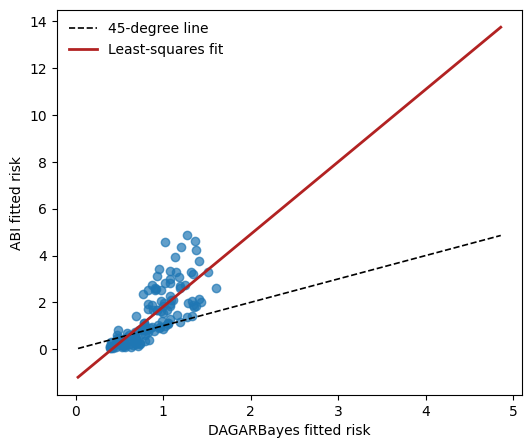

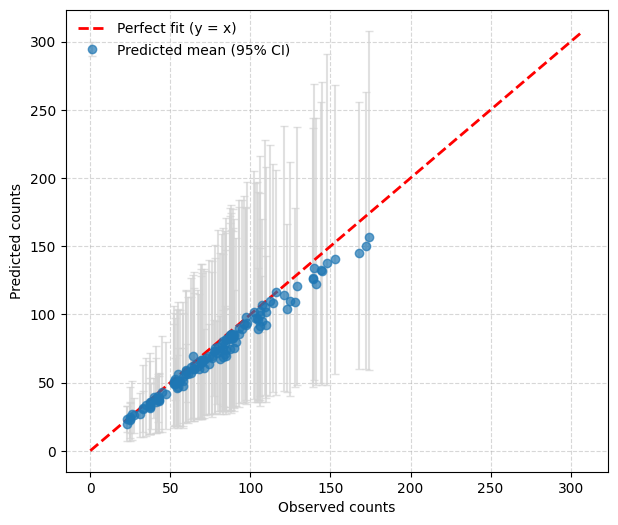

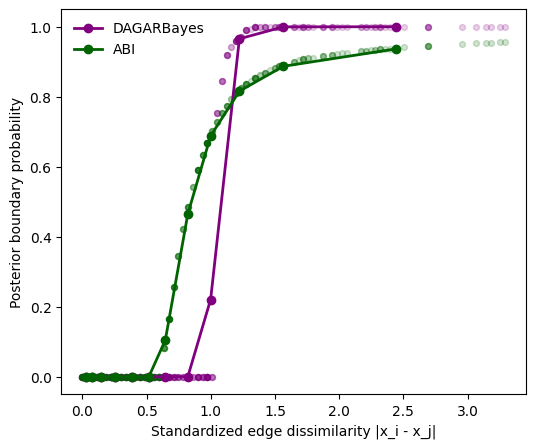

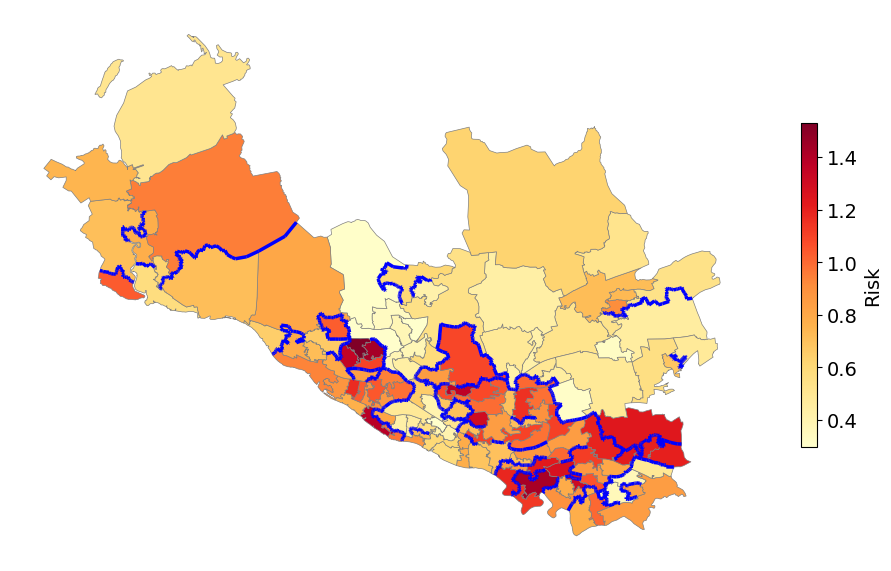

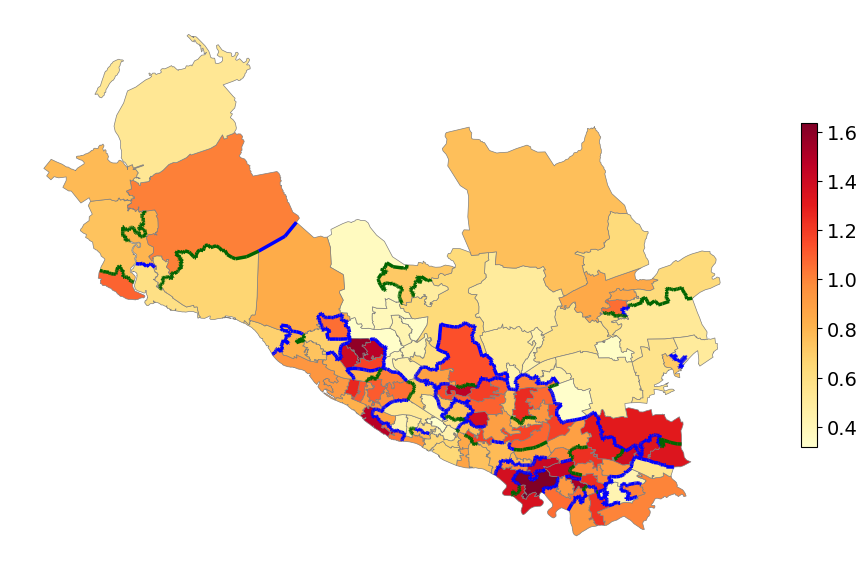

In [4]:
glasgow = run_application(workflow, APPLICATIONS["glasgow"])

print("Glasgow: posterior summary comparison")
display(glasgow["summary_compare"])

print("Glasgow: risk comparison metrics")
display(glasgow["risk_metrics"])

print("Glasgow: edge comparison metrics")
display(glasgow["edge_metrics"])

fig, _ = plot_risk_comparison(glasgow["area_compare"], "Glasgow risk comparison")
save_figure(fig, glasgow["output_dir"] / "glasgow_risk_comparison.png")
plt.show()

fig, _ = plot_posterior_predictive_check(
    glasgow["abi_script_plots"],
    "Glasgow posterior predictive check: node-level counts vs predictions"
)
save_figure(fig, glasgow["output_dir"] / "glasgow_post_pred_check.png")
plt.show()

fig, _ = plot_edge_probability_vs_dissimilarity(
    glasgow["edge_compare"],
    "Glasgow boundary probability versus edge dissimilarity"
)
save_figure(fig, glasgow["output_dir"] / "glasgow_edge_probability_vs_dissimilarity.png")
plt.show()

fig, _ = plot_fitted_risk_surface(
    glasgow["data"],
    glasgow["abi_script_plots"],
    glasgow["abi_edges"],
    APPLICATIONS["glasgow"],
    title="Glasgow fitted risk surface with ABI median-probability boundaries"
)
save_figure(fig, glasgow["output_dir"] / "glasgow_fitted_risk_surface.png")
plt.show()

fig, _ = plot_boundary_agreement(
    glasgow["data"],
    glasgow["edge_compare"],
    APPLICATIONS["glasgow"],
    title="Glasgow: median-probability boundary agreement (blue=both, green=ABI only, purple=DAGARBayes only)"
)
save_figure(fig, glasgow["output_dir"] / "glasgow_boundary_agreement.png")
plt.show()

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

California: posterior summary comparison


,comparison,abi_parameter,reference_parameter,abi_median,abi_lower_95,abi_upper_95,reference_median,reference_lower_95,reference_upper_95
0,intercept,beta_0,beta_0,0.085596,0.015099,0.151345,0.091253,0.072569,0.109054
1,variance_scale,sigma2_w,sigma2_w,0.106570,0.010548,0.833975,0.030103,0.016201,0.108308
2,boundary_strength,eta,eta,0.466910,0.016699,0.963603,0.438502,0.257877,0.725409
3,spatial_dependence,rho,rho,0.816915,0.050829,0.989423,0.570381,0.263040,0.878619


California: risk comparison metrics


,metric,value
0,correlation,0.859273
1,mae,0.152535
2,rmse,0.233232
3,abi_on_dagarbayes_slope,1.813486
4,abi_on_dagarbayes_intercept,-0.879657


California: edge comparison metrics


,metric,value
0,boundary_prob_correlation,0.844522
1,boundary_prob_mae,0.122921
2,abi_prob_vs_dissimilarity_corr,0.944771
3,dagarbayes_prob_vs_dissimilarity_corr,0.862906
4,median_boundary_count_abi,32.000000
5,median_boundary_count_dagarbayes,24.000000
6,median_boundary_overlap,24.000000
7,median_boundary_jaccard,0.750000


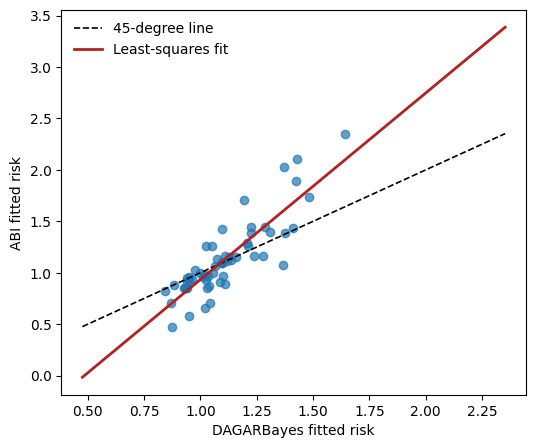

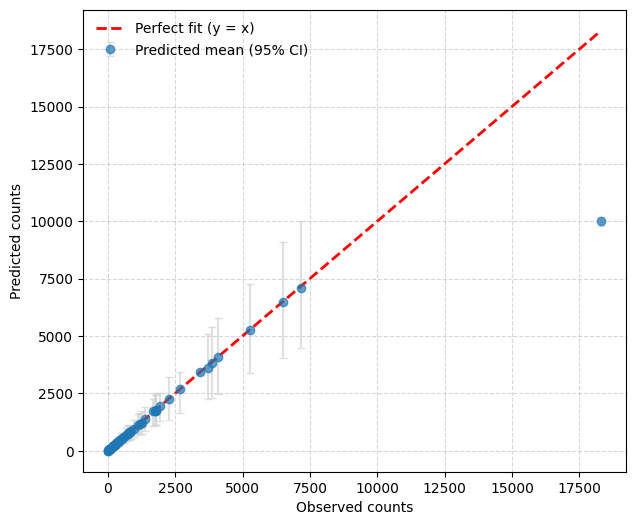

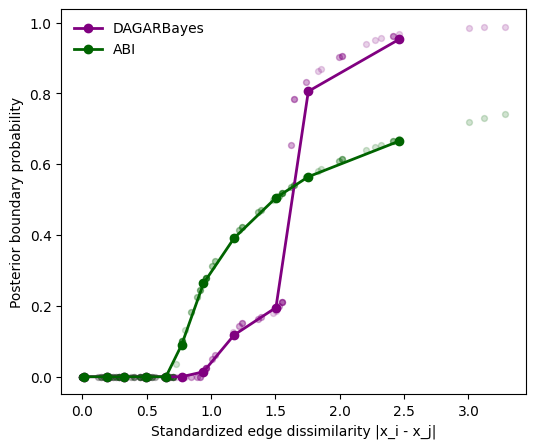

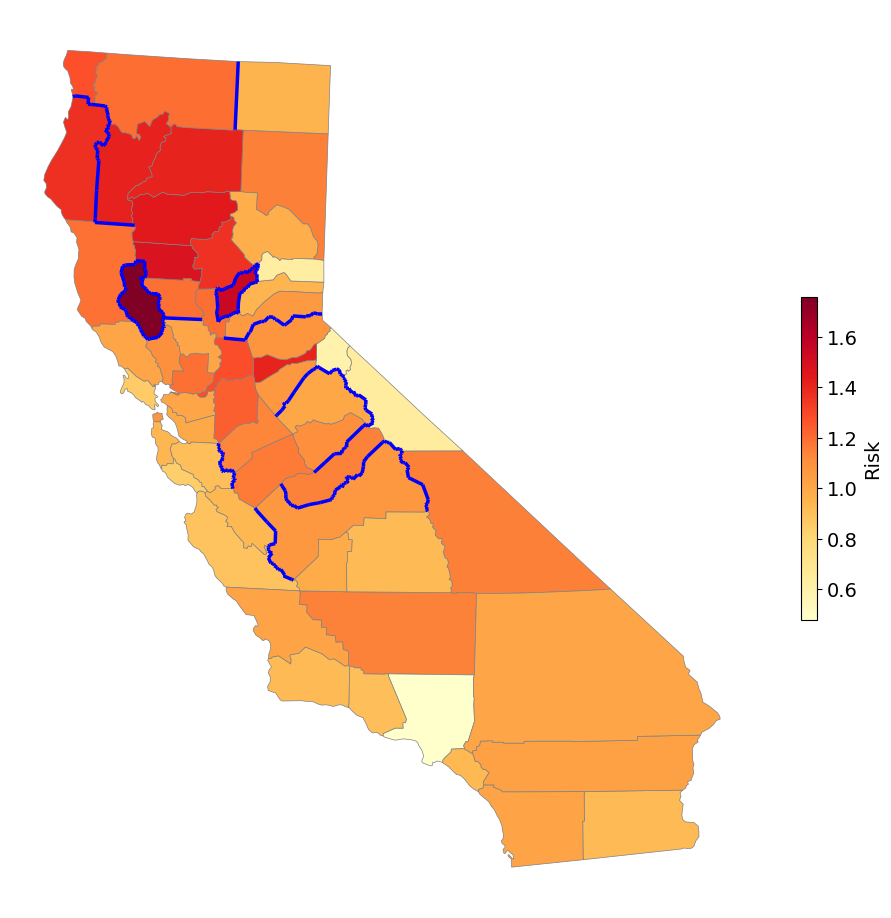

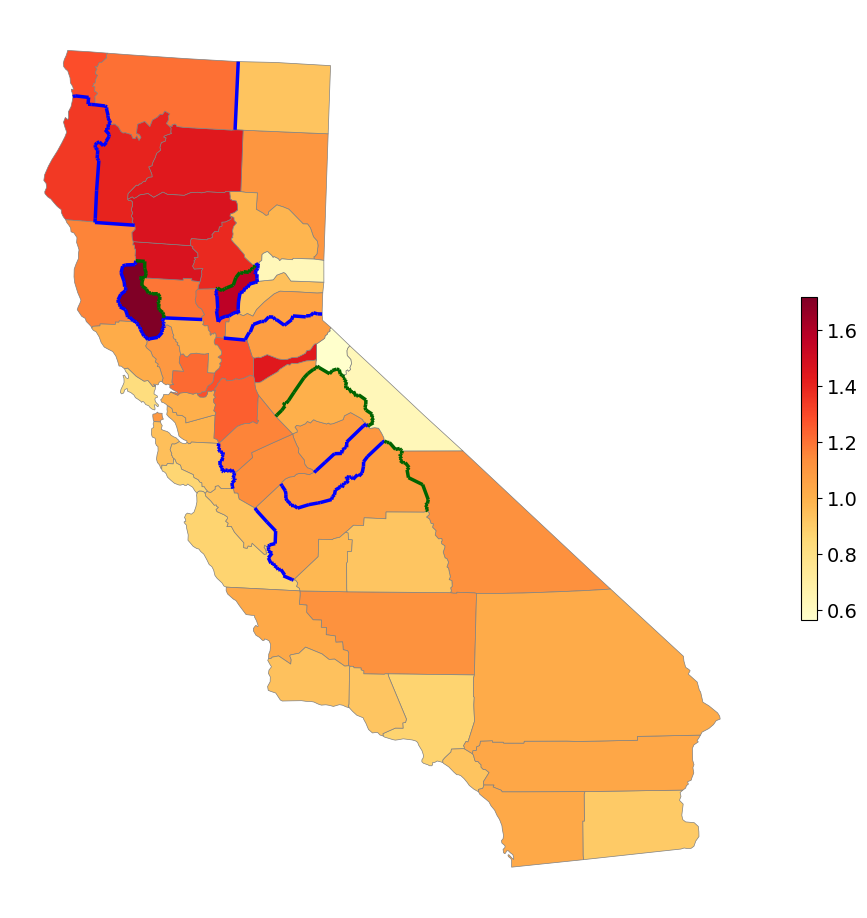

In [5]:
california = run_application(workflow, APPLICATIONS["california"])

print("California: posterior summary comparison")
display(california["summary_compare"])

print("California: risk comparison metrics")
display(california["risk_metrics"])

print("California: edge comparison metrics")
display(california["edge_metrics"])

fig, _ = plot_risk_comparison(california["area_compare"], "California risk comparison")
save_figure(fig, california["output_dir"] / "california_risk_comparison.png")
plt.show()

fig, _ = plot_posterior_predictive_check(
    california["abi_script_plots"],
    "California posterior predictive check: node-level counts vs predictions"
)
save_figure(fig, california["output_dir"] / "california_post_pred_check.png")
plt.show()

fig, _ = plot_edge_probability_vs_dissimilarity(
    california["edge_compare"],
    "California boundary probability versus edge dissimilarity"
)
save_figure(fig, california["output_dir"] / "california_edge_probability_vs_dissimilarity.png")
plt.show()

fig, _ = plot_fitted_risk_surface(
    california["data"],
    california["abi_script_plots"],
    california["abi_edges"],
    APPLICATIONS["california"],
    title="California fitted risk surface with ABI median-probability boundaries"
)
save_figure(fig, california["output_dir"] / "california_fitted_risk_surface.png")
plt.show()

fig, _ = plot_boundary_agreement(
    california["data"],
    california["edge_compare"],
    APPLICATIONS["california"],
    title="California: median-probability boundary agreement (blue=both, green=ABI only, purple=DAGARBayes only)"
)
save_figure(fig, california["output_dir"] / "california_boundary_agreement.png")
plt.show()

In [6]:
combined_risk_metrics = pd.concat([
    glasgow["risk_metrics"].assign(dataset="glasgow"),
    california["risk_metrics"].assign(dataset="california"),
], ignore_index=True)

combined_edge_metrics = pd.concat([
    glasgow["edge_metrics"].assign(dataset="glasgow"),
    california["edge_metrics"].assign(dataset="california"),
], ignore_index=True)

print("Combined risk metrics")
display(combined_risk_metrics)

print("Combined edge metrics")
display(combined_edge_metrics)

combined_risk_metrics.to_csv(COMPARISON_DIR / "combined_risk_metrics.csv", index=False)
combined_edge_metrics.to_csv(COMPARISON_DIR / "combined_edge_metrics.csv", index=False)
print("Saved comparison outputs under:", COMPARISON_DIR)

Combined risk metrics


,metric,value,dataset
0,correlation,0.775436,glasgow
1,mae,0.732848,glasgow
2,rmse,1.101022,glasgow
3,abi_on_dagarbayes_slope,3.096869,glasgow
4,abi_on_dagarbayes_intercept,-1.285168,glasgow
5,correlation,0.859273,california
6,mae,0.152535,california
7,rmse,0.233232,california
8,abi_on_dagarbayes_slope,1.813486,california
9,abi_on_dagarbayes_intercept,-0.879657,california


Combined edge metrics


,metric,value,dataset
0,boundary_prob_correlation,0.862614,glasgow
1,boundary_prob_mae,0.119296,glasgow
2,abi_prob_vs_dissimilarity_corr,0.893396,glasgow
3,dagarbayes_prob_vs_dissimilarity_corr,0.830480,glasgow
4,median_boundary_count_abi,134.000000,glasgow
5,median_boundary_count_dagarbayes,99.000000,glasgow
6,median_boundary_overlap,99.000000,glasgow
7,median_boundary_jaccard,0.738806,glasgow
8,boundary_prob_correlation,0.844522,california
9,boundary_prob_mae,0.122921,california


Saved comparison outputs under: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes


In [7]:
from PIL import Image
import numpy as np

MAP_PAIRS = [
    (
        glasgow["output_dir"] / "glasgow_boundary_agreement.png",
        california["output_dir"] / "california_boundary_agreement.png",
    ),
    (
        glasgow["output_dir"] / "glasgow_fitted_risk_surface.png",
        california["output_dir"] / "california_fitted_risk_surface.png",
    ),
]


def _content_bbox(image, tolerance=8):
    arr = np.array(image.convert("RGBA"))
    bg = arr[0, 0].astype(int)
    diff = np.max(np.abs(arr.astype(int) - bg), axis=2)
    mask = diff > tolerance
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return (0, 0, image.width, image.height)
    return (int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1)


def _column_clusters(mask, min_pixels=10):
    counts = mask.sum(axis=0)
    cols = np.where(counts > min_pixels)[0]
    if len(cols) == 0:
        return []
    gaps = np.where(np.diff(cols) > 1)[0]
    starts = [cols[0]] + [cols[i + 1] for i in gaps]
    ends = [cols[i] for i in gaps] + [cols[-1]]
    return [(int(start), int(end) + 1) for start, end in zip(starts, ends)]


def _split_map_and_legend(image, tolerance=8, merge_gap=60):
    arr = np.array(image.convert("RGBA"))
    bg = arr[0, 0].astype(int)
    diff = np.max(np.abs(arr.astype(int) - bg), axis=2)
    mask = diff > tolerance
    clusters = _column_clusters(mask)
    if len(clusters) < 2:
        return image.crop(_content_bbox(image)), None

    legend_start, _ = clusters[-1]
    idx = len(clusters) - 2
    while idx >= 0 and legend_start - clusters[idx][1] <= merge_gap:
        legend_start = clusters[idx][0]
        idx -= 1

    if idx < 0:
        return image.crop(_content_bbox(image)), None

    map_part = image.crop((0, 0, legend_start, image.height))
    legend_part = image.crop((legend_start, 0, image.width, image.height))
    return map_part.crop(_content_bbox(map_part)), legend_part.crop(_content_bbox(legend_part))


def _resize_to_height(image, target_height):
    if image is None or image.height == target_height:
        return image
    new_width = int(round(image.width * target_height / image.height))
    return image.resize((new_width, target_height), Image.Resampling.LANCZOS)


def _match_visible_map_height(path_left, path_right, overwrite=True, gap_px=120):
    with Image.open(path_left) as left_img_raw, Image.open(path_right) as right_img_raw:
        left_img = left_img_raw.convert("RGBA")
        right_img = right_img_raw.convert("RGBA")

        left_map, left_legend = _split_map_and_legend(left_img)
        right_map, right_legend = _split_map_and_legend(right_img)

        target_map_height = max(left_map.height, right_map.height)
        left_map = _resize_to_height(left_map, target_map_height)
        right_map = _resize_to_height(right_map, target_map_height)

        legend_images = [image for image in (left_legend, right_legend) if image is not None]
        target_legend_height = min(image.height for image in legend_images) if legend_images else 0
        left_legend = _resize_to_height(left_legend, target_legend_height)
        right_legend = _resize_to_height(right_legend, target_legend_height)

        legend_canvas_width = max((image.width for image in (left_legend, right_legend) if image is not None), default=0)
        left_group_width = left_map.width + (gap_px if left_legend is not None else 0) + (left_legend.width if left_legend is not None else 0)
        right_group_width = right_map.width + (gap_px if right_legend is not None else 0) + (right_legend.width if right_legend is not None else 0)
        canvas_width = max(left_group_width, right_group_width)
        canvas_height = max(target_map_height, target_legend_height)
        background = tuple(int(x) for x in np.array(left_img)[0, 0])

        def _compose(map_image, legend_image):
            canvas = Image.new("RGBA", (canvas_width, canvas_height), background)
            group_width = map_image.width + (gap_px if legend_image is not None else 0) + (legend_image.width if legend_image is not None else 0)
            x0 = (canvas_width - group_width) // 2
            map_y = (canvas_height - map_image.height) // 2
            canvas.paste(map_image, (x0, map_y), map_image)
            if legend_image is not None:
                legend_x = x0 + map_image.width + gap_px
                legend_y = (canvas_height - legend_image.height) // 2
                canvas.paste(legend_image, (legend_x, legend_y), legend_image)
            return canvas

        left_final = _compose(left_map, left_legend)
        right_final = _compose(right_map, right_legend)

        if overwrite:
            left_out = path_left
            right_out = path_right
        else:
            left_out = path_left.with_stem(path_left.stem + "_same_height")
            right_out = path_right.with_stem(path_right.stem + "_same_height")

        left_final.save(left_out)
        right_final.save(right_out)

        print(
            f"Matched visible map height for {path_left.name} and {path_right.name}: "
            f"map height {target_map_height}px, legend height {target_legend_height}px, "
            f"canvas {canvas_width}x{canvas_height}px"
        )
        print(f"Saved: {left_out}")
        print(f"Saved: {right_out}")


for left_path, right_path in MAP_PAIRS:
    _match_visible_map_height(left_path, right_path, overwrite=True)


Matched visible map height for glasgow_boundary_agreement.png and california_boundary_agreement.png: map height 2453px, legend height 975px, canvas 3597x2453px
Saved: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes\glasgow\glasgow_boundary_agreement.png
Saved: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes\california\california_boundary_agreement.png
Matched visible map height for glasgow_fitted_risk_surface.png and california_fitted_risk_surface.png: map height 2453px, legend height 975px, canvas 3667x2453px
Saved: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes\glasgow\glasgow_fitted_risk_surface.png
Saved: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes\california\california_fitted_risk_surface.png


In [8]:
from matplotlib.backends.backend_pdf import PdfPages


def running_mean(samples):
    samples = np.asarray(samples, dtype=float)
    if samples.size == 0:
        return samples
    return np.cumsum(samples) / np.arange(1, samples.size + 1)


def autocorrelation_values(samples, max_lag=100):
    samples = np.asarray(samples, dtype=float)
    n = samples.size
    if n <= 1:
        return np.array([0]), np.array([1.0])

    centered = samples - samples.mean()
    denom = np.dot(centered, centered)
    max_lag = int(min(max_lag, n - 1))
    lags = np.arange(0, max_lag + 1)
    acf = np.empty(max_lag + 1, dtype=float)
    acf[0] = 1.0

    if denom <= 0:
        acf[1:] = 0.0
        return lags, acf

    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(centered[:-lag], centered[lag:]) / denom

    return lags, acf


ABI_DIAGNOSTIC_LABELS = {
    "beta_0": r"$\beta_0$",
    "sigma_w^2": r"$\sigma_w^2$",
    "eta": r"$\eta$",
    "rho": r"$\rho$",
}


def extract_abi_diagnostic_samples(result):
    post_draws = result["post_draws"]
    m_real = float(result["data"]["M_real"])
    return {
        "beta_0": np.asarray(post_draws["beta"][0, :, 0], dtype=float),
        "sigma_w^2": np.asarray(post_draws["sigma2_w"][0, :, 0], dtype=float),
        "eta": np.asarray(post_draws["eta_raw"][0, :, 0], dtype=float) * m_real,
        "rho": np.asarray(post_draws["rho"][0, :, 0], dtype=float),
    }


def save_abi_diagnostics(result, dataset_name):
    parameter_samples = extract_abi_diagnostic_samples(result)
    output_path = result["output_dir"] / f"{dataset_name}_abi_diagnostics.pdf"

    with PdfPages(output_path) as pdf:
        for parameter_name, samples in parameter_samples.items():
            label = ABI_DIAGNOSTIC_LABELS.get(parameter_name, parameter_name)
            iterations = np.arange(1, samples.size + 1)
            lags, acf = autocorrelation_values(samples, max_lag=min(100, max(samples.size - 1, 1)))

            fig, axes = plt.subplots(3, 1, figsize=(8, 11))

            axes[0].plot(iterations, samples, color="black", linewidth=0.6)
            axes[0].set_title(f"{label} traceplot")
            axes[0].set_xlabel("Iteration")
            axes[0].set_ylabel("Value")
            axes[0].grid(alpha=0.2)

            axes[1].axhline(0.0, color="gray", linewidth=0.8)
            axes[1].vlines(lags, 0.0, acf, color="black", linewidth=1.0)
            axes[1].plot(lags, acf, "o", color="black", markersize=3)
            axes[1].set_title(f"{label} autocorrelation")
            axes[1].set_xlabel("Lag")
            axes[1].set_ylabel("ACF")
            axes[1].grid(alpha=0.2)

            axes[2].plot(iterations, running_mean(samples), color="black", linewidth=0.8)
            axes[2].set_title(f"{label} running mean")
            axes[2].set_xlabel("Iteration")
            axes[2].set_ylabel("Running mean")
            axes[2].grid(alpha=0.2)

            fig.suptitle(f"{dataset_name.title()} ABI posterior diagnostics", fontsize=13)
            fig.tight_layout(rect=[0, 0, 1, 0.97])
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved ABI diagnostics: {output_path}")


for dataset_name, result in (("glasgow", glasgow), ("california", california)):
    save_abi_diagnostics(result, dataset_name)


Saved ABI diagnostics: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes\glasgow\glasgow_abi_diagnostics.pdf
Saved ABI diagnostics: c:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Real Data Analysis\results_ABI_vs_DAGARBayes\california\california_abi_diagnostics.pdf
